In [ ]:
from queue import PriorityQueue
from math import sqrt
class Graph:
    def __init__(self, num_of_vertices):
        self.v = num_of_vertices
        # edges is a 2d array of weights from node i to node j
        self.edges = [[(-1,-1) for j in range(num_of_vertices)] for i in range(num_of_vertices)]

        # nodeCoords is an array containing the longitudal and latitudal coordinates
        self.nodeCoords = [(0,0) for i in range(num_of_vertices)]

        # visited is an array containing the nodes assessed throughout the pathfinding process
        self.visited = []

    def add_edge(self, i, j, busyTraffic, roadId):
        # TODO: change distance multiplier
        wt = self.euclidean(self.nodeCoords[i],self.nodeCoords[j])*10
        if busyTraffic:
          wt = wt*1.5
        self.edges[i][j] = (wt, roadId)
        self.edges[j][i] = (wt, roadId)
        return wt

    def add_node_coord(self, u, coord):
        self.nodeCoords[u] = coord
      
    def euclidean(self, p, q):
        return sqrt((q[0]-p[0])**2 + (q[1]-p[1])**2)
    
    def manhattan(self, p, q):
        return abs(q[0]-p[0]) + abs(q[1]-p[1])

    def reconstruct_path(self, cameFrom, current):
        total_path = [current]
        while current in cameFrom:           
            current = cameFrom[current]
            total_path.append(current)
            
        return total_path
            

    def a_star(self, start_vertex, end_vertex, isDijkstra=False):
        gScore = {v:float('inf') for v in range(self.v)}
        gScore[start_vertex] = 0
        fScore =  {v:float('inf') for v in range(self.v)}
        fScore[start_vertex] = 0
        # turnScore = {v:0 for v in range(self.v)}
        visitedNeighbors = []
        cameFrom = {v:-1 for v in range(self.v)}

        pq = PriorityQueue()
        pq.put((0, start_vertex))
        pqSet = {start_vertex: True}

        while not pq.empty():
            # Get the next node with the lowest f score
            f, current_vertex = pq.get()
            del pqSet[current_vertex]
            self.visited.append(current_vertex)

            # If the node is the destination, break out of the loop
            if current_vertex == end_vertex:
                return [self.reconstruct_path(cameFrom, current_vertex), fScore, visitedNeighbors]

            for neighbor in range(self.v):
                weight, roadId = self.edges[current_vertex][neighbor]
                if weight != -1:
                    visitedNeighbors.append(current_vertex)
                    tentative_gScore = gScore[current_vertex] + weight
                    
                    # If the current path to neighbor is bettwe than any previous path to neighbor ..
                    if tentative_gScore < gScore[neighbor]:
                        # Change hScore to 0 to test dijkstra
                        hScore = 0 if isDijkstra else self.manhattan(self.nodeCoords[current_vertex], self.nodeCoords[end_vertex])*10 # Change distance weight accordingly
                        cameFrom[neighbor] = current_vertex
                        gScore[neighbor] = tentative_gScore
                        fScore[neighbor] = tentative_gScore + hScore

                        if neighbor not in pqSet:
                            pq.put((tentative_gScore + hScore, neighbor))
                            pqSet[neighbor] = True

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pylab
def plot_graph(edges, nodes, path, visitedNeighbors):
  G = nx.DiGraph()
  color_map=["lightgray"]*len(nodes)
  for node in visitedNeighbors:
    color_map[node] = "gray"
  color_map[path[0]] = "lightblue"
  color_map[path[-2]] = "lightblue"
  for node in nodes:
    pos = node[1:][0]
    G.add_node(node[0], pos=pos)
  for edge in edges:
    G.add_edges_from([edge[:2]], weight=edge[2])
  red_edges = []
  for i in  range(len(path)-1):
    red_edges.append((path[i],path[i+1]))
    red_edges.append((path[i+1],path[i]))

  edge_labels=dict([((u,v,),d['weight']) for u,v,d in G.edges(data=True)])
  edge_colors = ['red' if not edge in red_edges else 'green' for edge in G.edges()]
  plt.figure(1,figsize=(9,9)) 
  nx.draw_networkx_edge_labels(G,nx.get_node_attributes(G, 'pos'),edge_labels=edge_labels)
  nx.draw(G,nx.get_node_attributes(G, 'pos'), arrows=False, with_labels=True,node_color=color_map, node_size=1000,edge_color=edge_colors, width=5)
  
  plt.show()

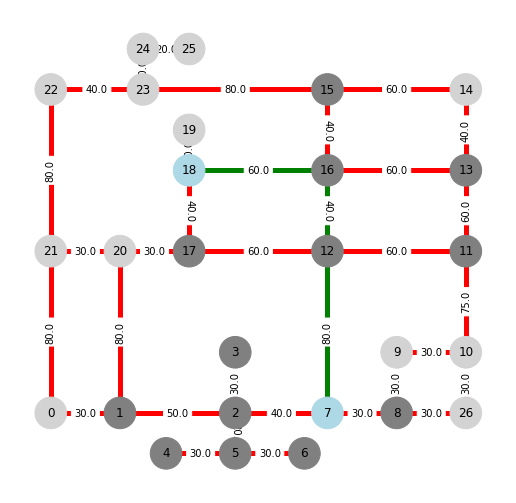

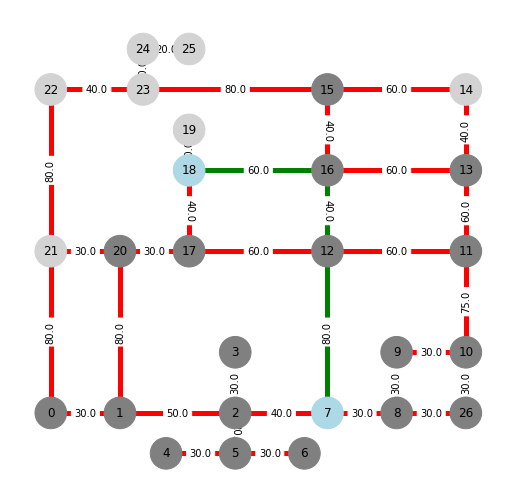

In [147]:

# i, j, busyTraffic, roadId
edges = [
    [0,1,False,0],
    [0,21,False,6],
    [1,2,False,0],
    [1,20,False,7],
    [2,3,False,2],
    [2,5,False,2],
    [5,4,False,1],
    [5,6,False,1],
    [2,7,False,0],
    [7,8,False,0],
    [7,12,False,9],
    [8,26,False,0],
    [8,9,False,12],
    [9,10,False,11],
    [26,10,False,10],
    [10,11,True,10],
    [11,12,False,3],
    [11,13,True,10],
    [13,14,False,10],
    [13,16,False,4],
    [14,15,False,5],
    [15,16,False,9],
    [15,23,False,5],
    [16,12,False,9],
    [16,18,False,4],
    [18,19,False,8],
    [18,17,False,8],
    [17,20,False,3],
    [17,12,False,3],
    [20,21,False,3],
    [21,22,False,6],
    [22,23,False,5],
    [23,24,False,13],
    [24,25,False,14],
]
# id, coord
nodes = [
    [0,(-10,-8)],
    [1,(-7,-8)],
    [2,(-2,-8)],
    [3,(-2,-5)],
    [4,(-5,-10)],
    [5,(-2,-10)],
    [6,(1,-10)],
    [7,(2,-8)],
    [8,(5,-8)],
    [9,(5,-5)],
    [10,(8,-5)],
    [11,(8,0)],
    [12,(2,0)],
    [13,(8,4)],
    [14,(8,8)],
    [15,(2,8)],
    [16,(2,4)],
    [17,(-4,0)],
    [18,(-4,4)],
    [19,(-4,6)],
    [20,(-7,0)],
    [21,(-10,0)],
    [22,(-10,8)],
    [23,(-6,8)],
    [24,(-6,10)],
    [25,(-4,10)],
    [26,(8,-8)],
]
g = Graph(len(edges))
edges_with_weights = []
for node in nodes:
    g.add_node_coord(*node)
for edge in edges:
    weight = g.add_edge(*edge)
    edges_with_weights.append([*edge[:2],weight])

# Run A-star by passing: Starting node, Ending node
start_node = 7
end_node = 18
a_star_result = g.a_star(start_node,end_node)
dijkstra_result = g.a_star(start_node,end_node,True)

plot_graph(edges_with_weights, nodes, a_star_result[0], a_star_result[2])
plot_graph(edges_with_weights, nodes, dijkstra_result[0], dijkstra_result[2])

10
10
10
10
10
10
10
10
10
10
10
10
10
{0: 0, 1: 15, 2: 15, 3: 24, 4: 24, 5: 33, 6: 42, 7: 33, 8: 51, 9: 33, 10: 42, 11: inf, 12: inf}


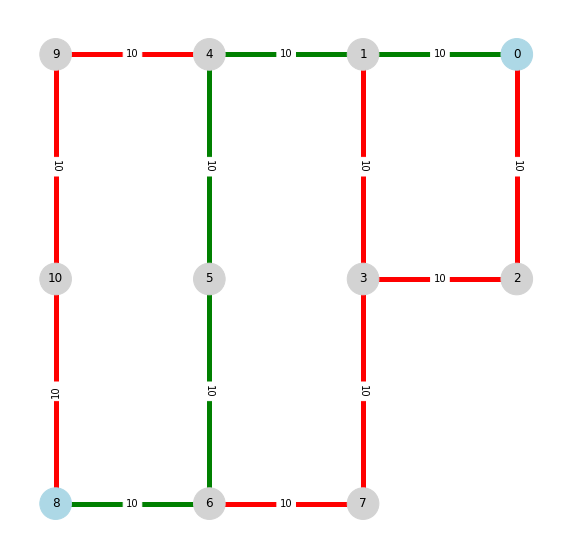

In [ ]:
# Old example
# i, j, busyTraffic, roadId
edges = [
    [0,1,False,0],
    [0,2,False,1],
    [1,4,False,0],
    [1,3,False,2],
    [2,3,False,3],
    [3,7,False,2],
    [4,5,False,4],
    [4,9,False,0],
    [5,6,False,4],
    [6,7,False,5],
    [6,8,False,5],
    [8,10,False,6],
    [9,10,False,6]
]
# id, coord
nodes = [
    [0,(3,2)],
    [1,(2,2)],
    [2,(3,1)],
    [3,(2,1)],
    [4,(1,2)],
    [5,(1,1)],
    [6,(1,0)],
    [7,(2,0)],
    [8,(0,0)],
    [9,(0,2)],
    [10,(0,1)]
]
g = Graph(len(edges))
edges_with_weights = []
for node in nodes:
    g.add_node_coord(*node)
for edge in edges:
    weight = g.add_edge(*edge)
    edges_with_weights.append([*edge[:2],weight])

# print(g.edges)
result = g.a_star(0,8)
print(result[1])
plot_graph(edges_with_weights, nodes, result[0])